In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize

import jaxpm
from jaxpm import camels, plotting, hpm, nn, graph, diagnostics, objectives
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, ScaleConditionedCNN
from jaxpm.objectives import ParticleLoss, FieldLoss

print(jax.default_backend())

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


gpu


# configuration

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
# mesh_per_dim = 2 * parts_per_dim

# parts_per_dim = 128
# mesh_per_dim = parts_per_dim

# parts_per_dim = None
# mesh_per_dim = 256

mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# CAMELS

In [4]:
CODE = "SIMBA"
# CODE = "ASTRID"
# CODE = "IllustrisTNG"

train_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

vali_dict = camels.load_CV_snapshots(
    "CV_1",
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=None,
    CAMELS="/pscratch/sd/a/athomsen/flatiron/CAMELS",
    CODE=CODE,
)

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=64,mesh=64.h5
Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_1/parts=64,mesh=64.h5


In [5]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

In [6]:
def train_step_base(model, optimizer, loss_fn_wrapper):
    loss, grads = nnx.value_and_grad(loss_fn_wrapper)(model)
    optimizer.update(grads)

    squared_sum = jax.tree_util.tree_reduce(
            lambda x, y: x + jnp.sum(y**2),
            grads,
            0.0
        )
    grad_norm = jnp.sqrt(squared_sum)

    return loss, grad_norm

def loss_base(
    loss_instance,
    y0,
    t0,
    ref_t, 
    ref_poss,
    ref_vels=None,
    ref_cls=None,
    ref_deltas=None,
    gravity_model=None, 
    pressure_model=None, 
    species="gas",
):
    # integrate
    res = solve_ode(y0, t0, ref_t, gravity_model, pressure_model)
    if species == "dm":
        res_poss, res_vels = res[0], res[1]
    elif species == "gas":
        res_poss, res_vels = res[2], res[3]
    else:
        raise NotImplementedError

    return loss_instance(
        res_poss,
        res_vels,
        ref_poss,
        ref_vels,
        ref_cls,
        ref_deltas,
    )

@nnx.jit(static_argnames=("loss_instance", "model_to_train"))
def train_step(
    loss_instance,
    optimizer,
    y0,
    t0,
    ref_t, 
    ref_poss, 
    ref_vels=None,
    ref_cls=None,
    ref_deltas=None,
    gravity_model=None,
    pressure_model=None,
    # static
    model_to_train="pressure",
):
    """dynamic snapshot range as passed"""

    if model_to_train == "pressure":
        def loss_fn_wrapper(model):
            return loss_base(
                loss_instance,
                y0, 
                t0,
                ref_t, 
                ref_poss, 
                ref_vels,
                ref_cls, 
                ref_deltas,
                gravity_model=gravity_model, 
                pressure_model=model, 
                species="gas",
            )

        return train_step_base(pressure_model, optimizer, loss_fn_wrapper)

    elif model_to_train == "gravity":
        def loss_fn_wrapper(model):
            return loss_base(
                loss_instance,
                y0, 
                t0,
                ref_t, 
                ref_poss, 
                ref_vels,
                ref_cls, 
                ref_deltas,
                gravity_model=model, 
                pressure_model=pressure_model, 
                species="dm",
            )

        return train_step_base(gravity_model, optimizer, loss_fn_wrapper)


# @nnx.jit(static_argnames=("loss_instance", "model_to_train"))
# def train_step(
#     loss_instance,
#     optimizer,
#     y0,
#     t0,
#     ref_t, 
#     ref_poss, 
#     ref_vels=None,
#     ref_cls=None,
#     ref_deltas=None,
#     gravity_model=None,
#     pressure_model=None,
#     # static
#     model_to_train="pressure",
# ):
#     """dynamic snapshot range as passed"""

#     def loss_fn_wrapper(model):
        
#         if model_to_train == "pressure":
#             gravity_model = gravity_model
#             pressure_model = model
#             species = "gas"
#         elif model_to_train == "gravity":
#             gravity_model = model
#             pressure_model = pressure_model
#             species = "dm"

#         return loss_base(
#                 loss_instance,
#                 y0, 
#                 t0,
#                 ref_t, 
#                 ref_poss, 
#                 ref_vels,
#                 ref_cls, 
#                 ref_deltas,
#                 gravity_model=gravity_model, 
#                 pressure_model=pressure_model, 
#                 species=species,
#             )

#     if model_to_train == "pressure":
#         return train_step_base(pressure_model, optimizer, loss_fn_wrapper)
#     elif model_to_train == "gravity":
#         return train_step_base(gravity_model, optimizer, loss_fn_wrapper)
#     else:
#         raise ValueError



# @nnx.jit(static_argnames=("particle_loss", "model_to_train"))
# def train_step_particle(
#     particle_loss,
#     optimizer,
#     y0,
#     t0,
#     ref_t, 
#     ref_poss, 
#     ref_vels=None,
#     ref_cls=None,
#     ref_deltas=None,
#     gravity_model=None,
#     pressure_model=None,
#     # static
#     model_to_train="pressure",
# ):
#     """dynamic snapshot range as passed"""

#     if model_to_train == "pressure":
#         def loss_fn_wrapper(model):
#             return particle_loss_wrapper(
#                 particle_loss,
#                 y0, 
#                 t0,
#                 ref_t, 
#                 ref_poss, 
#                 ref_vels,
#                 ref_cls, 
#                 ref_deltas,
#                 gravity_model=gravity_model, 
#                 pressure_model=model, 
#                 species="gas",
#             )

#         return train_step_base(pressure_model, optimizer, loss_fn_wrapper)

#     elif model_to_train == "gravity":
#         def loss_fn_wrapper(model):
#             return particle_loss_wrapper(
#                 particle_loss,
#                 y0, 
#                 t0,
#                 ref_t, 
#                 ref_poss, 
#                 ref_vels,
#                 ref_cls, 
#                 ref_deltas,
#                 gravity_model=model, 
#                 pressure_model=pressure_model, 
#                 species="dm",
#             )

#         return train_step_base(gravity_model, optimizer, loss_fn_wrapper)
    
# @nnx.jit(static_argnames=("field_loss"))
# def train_step_field(
#     field_loss,
#     optimizer,
#     y0,
#     t0,
#     ref_t, 
#     ref_poss, 
#     ref_vels=None,
#     ref_cls=None,
#     ref_deltas=None,
#     gravity_model=None,
#     pressure_model=None,
# ):
#     """dynamic snapshot range as passed"""

#     def loss_fn_wrapper(model):
#         return field_loss_wrapper(
#             field_loss,
#             y0, 
#             t0,
#             ref_t, 
#             ref_poss, 
#             ref_vels,
#             ref_cls, 
#             ref_deltas,
#             gravity_model=gravity_model,
#             pressure_model=model, 
#             species="gas",
#         )

#     return train_step_base(pressure_model, optimizer, loss_fn_wrapper)

In [7]:
# dt0 = 0.001
# dt0 = 0.1
dt0 = 0.01
# dt0 = 0.005

scales = train_dict["scales"]
print(np.diff(scales))
assert np.all(np.diff(scales) > dt0)

# edges = graph.get_edges(train_dict["gas_poss"], scales, k=4)

def solve_ode(y0, t0, ts, gravity_model, pressure_model, training=True):
    ode = ODETerm(
        hpm.get_hpm_network_ode_fn(
            mesh_per_dim, 
            cosmo, 
            gravity_model=gravity_model, 
            pressure_model=pressure_model, 
            training=training,
            # precomputed_edges=edges,
        )
    )

    res = diffeqsolve(
            terms=ode,
            solver=LeapfrogMidpoint(),
            t0=t0,
            t1=ts[-1],
            dt0=dt0,
            y0=y0,
            saveat=SaveAt(ts=ts),
            max_steps=1000,
            stepsize_controller=ConstantStepSize(),
        )
    res = res.ys

    return res


[0.02380952 0.03333333 0.02222222 0.02777778 0.01224106 0.01284044
 0.01346916 0.01412867 0.01482047 0.01554614 0.01630734 0.01710582
 0.0179434  0.01882198 0.01974359 0.02071031 0.02172438 0.0227881
 0.0239039  0.02507434 0.02630208 0.02758995 0.02894087 0.03035793
 0.03184439 0.03340362 0.03503921 0.03675488 0.03855455 0.04044235
 0.04242258 0.04449977 0.04667867]


# loss

### CAMELS ground truth

In [8]:
# general
cosmo = train_dict["cosmo"]
scales = train_dict["scales"]

# particles
dm_poss = train_dict["dm_poss"]
dm_vels = train_dict["dm_vels"]

gas_poss = train_dict["gas_poss"]
gas_vels = train_dict["gas_vels"]

# fields
dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass

rhos_dm = vcic_paint(jnp.zeros(mesh_shape), dm_poss, dm_mass)
deltas_dm = rhos_dm/rhos_dm.mean() - 1

rhos_gas = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
deltas_gas = rhos_gas/rhos_gas.mean() - 1

# power spectrum
_, cls_dm = objectives.vpower_spectrum(deltas_dm)
_, cls_gas = objectives.vpower_spectrum(deltas_gas)

In [9]:
# def loss_wrapper(
#     loss_instance,
#     y0,
#     t0,
#     ref_t, 
#     ref_poss,
#     ref_vels=None,
#     ref_cls=None,
#     ref_deltas=None,
#     gravity_model=None, 
#     pressure_model=None, 
#     species="gas",
# ):
#     # integrate
#     res = solve_ode(y0, t0, ref_t, gravity_model, pressure_model)
#     if species == "dm":
#         res_poss, res_vels = res[0], res[1]
#     elif species == "gas":
#         res_poss, res_vels = res[2], res[3]
#     else:
#         raise NotImplementedError

#     return loss_instance(
#         res_poss,
#         res_vels,
#         ref_poss,
#         ref_vels,
#         ref_cls,
#         ref_deltas,
#     )


### particle-level

In [10]:
# def particle_loss_wrapper(
#     particle_loss,
#     y0,
#     t0,
#     ref_t, 
#     ref_poss,
#     ref_vels=None,
#     ref_cls=None,
#     ref_deltas=None,
#     gravity_model=None, 
#     pressure_model=None, 
#     species="gas",
# ):
#     # integrate
#     res = solve_ode(y0, t0, ref_t, gravity_model, pressure_model)
#     if species == "dm":
#         res_poss, res_vels = res[0], res[1]
#     elif species == "gas":
#         res_poss, res_vels = res[2], res[3]
#     else:
#         raise NotImplementedError

#     loss = particle_loss(
#         res_poss,
#         res_vels,
#         ref_poss,
#         ref_vels,
#         ref_cls,
#         ref_deltas,
#     )

#     return loss


### field-level

In [11]:
# def field_loss_wrapper(
#     field_loss,
#     y0,
#     t0,
#     ref_t, 
#     ref_poss,
#     ref_vels=None,
#     ref_cls=None,
#     ref_deltas=None,
#     gravity_model=None, 
#     pressure_model=None, 
#     species="gas",
# ):
#     # integrate
#     res = solve_ode(y0, t0, ref_t, gravity_model, pressure_model)
#     if species == "dm":
#         res_poss, res_vels = res[0], res[1]
#     elif species == "gas":
#         res_poss, res_vels = res[2], res[3]
#     else:
#         raise NotImplementedError

#     loss = field_loss(
#         res_poss,
#         res_vels,
#         ref_deltas,
#         ref_cls,
#     )

#     return loss


# gravity correction

In [12]:
i_plot = range(0, 32+8, 8)

In [13]:
gravity_model = nn.NeuralSplineFourierFilterNNX(n_knots=8, d_latent=16, rngs=nnx.Rngs(0))
gravity_loss = ParticleLoss(mesh_per_dim, w_pos=1.0, w_cls=0.1)

In [14]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# checkpoint_file = os.path.join(os.getcwd(), f"checkpoints/gravity_fourier_spline_parts={parts_per_dim},mesh={mesh_per_dim},dt={dt0}.jx")
# checkpointer = ocp.StandardCheckpointer()

# try:
#     abstract_model = nnx.eval_shape(lambda: gravity_model)
#     graphdef, abstract_params = nnx.split(abstract_model)
    
#     params = checkpointer.restore(checkpoint_file, abstract_params)
#     gravity_model = nnx.merge(graphdef, params)
#     print(f"successfully restored model from {checkpoint_file}")
# except:
#     print("failed to load model")

## training

In [15]:
total_steps = 300
learning_rate = 1e-3
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-3, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
clip_norm = 1

gravity_optimizer = nnx.ModelAndOptimizer(
    gravity_model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []
grad_norms = []

In [17]:
# evaluating the loss for all snapshots is computationally feasible
for i in (pbar := tqdm.tqdm(range(total_steps))):
    i0 = 0
    y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
    t0 = scales[i0]
    
    loss, grad_norm = train_step(
        gravity_loss,
        gravity_optimizer, 
        y0, 
        t0,
        scales,
        ref_poss=dm_poss, 
        ref_cls=cls_dm,
        ref_deltas=deltas_dm,
        gravity_model=gravity_model,
        pressure_model=None,
        # model_to_train="gravity",
        model_to_train="pressure",
    )

    losses.append(loss)
    pbar.set_description(f"Loss: {loss:.4f}")

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

  0%|          | 0/300 [00:00<?, ?it/s]


UnboundLocalError: cannot access local variable 'gravity_model' where it is not associated with a value

In [17]:
# _, params = nnx.split(gravity_model)
# checkpointer.save(checkpoint_file, params, force=True)

In [18]:
for camels_dict in [train_dict, vali_dict]:
    diagnostics.run_simulations(
        camels_dict,
        mesh_per_dim,
        gravity_model=gravity_model, 
        dt0=dt0,
        i_plot=i_plot,
        plot_dm=True,
        plot_gas=False,
    )

# pressure correction

### MLP

In [41]:
pressure_model = MLP(
    d_in=5,
    d_out=1, 
    # d_hidden=16, 
    d_hidden=64, 
    # d_hidden=128,
    # d_hidden=256,
    n_hidden=4, 
    # n_hidden=2, 
    # dropout_rate=0.01,
    dropout_rate=0.0,
    rngs=nnx.Rngs(0),
    norm_type="layer",
    # norm_type="batch",
    activation=jax.nn.swish,
)

pressure_loss = ParticleLoss(
    mesh_per_dim,
    w_pos=1.0,
    w_vel=0.1,
    w_cls=0.1,
    w_cross=0.0,
    w_snapshot=0.0,
)

learning_rate = 1e-4
# learning_rate = 1e-5

ERROR! Session/line number was not unique in database. History logging moved to new session 9656


### CNN

In [42]:
# # pressure_model = ScaleConditionedCNN(
# #     d_in=4, 
# #     d_out=1,
# #     # d_hidden=16,
# #     d_hidden=64,
# #     # d_hidden=128,
# #     # d_hidden=256,
# #     # n_hidden=4,
# #     n_hidden=4,
# #     # kernel_size=(3, 3, 3),
# #     kernel_size=(5, 5, 5),
# #     rngs=nnx.Rngs(0),
# #     norm_type="layer",
# #     activation=jax.nn.swish,
# #     use_residual=True,
# # )

# pressure_model = ScaleConditionedCNN(
#     d_in=4, 
#     d_out=1,
#     d_hidden=128,
#     n_hidden=2,
#     kernel_size=(5, 5, 5),
#     rngs=nnx.Rngs(0),
#     norm_type="layer",
#     activation=jax.nn.swish,
#     use_residual=True,
# )


# pressure_loss = FieldLoss(
#     mesh_per_dim,
#     w_field=1.0,
#     w_cls=0.0,
#     w_cross=0.0,
#     w_snapshot=0.0,
# )

# # pressure_loss = ParticleLoss(
# #     mesh_per_dim,
# #     w_pos=1.0,
# #     w_vel=0.1,
# #     w_cls=0.1,
# #     w_cross=0.0,
# #     w_snapshot=0.0,
# # )

# learning_rate = 1e-5

## training

In [43]:
def train_step_wrapper(i0=0, i_loss=None):
    y0 = (dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0])
    t0 = scales[i0]
    
    if all_steps := (i_loss is None):
        i_loss = np.arange(0, len(scales))

    if isinstance(pressure_loss, jaxpm.objectives.ParticleLoss):
        loss, grad_norm = train_step_particle(
            pressure_loss,
            pressure_optimizer, 
            y0, 
            t0,
            ref_t=scales[i_loss], 
            ref_poss=gas_poss[i_loss], 
            ref_vels=gas_vels[i_loss],
            ref_cls=cls_gas[i_loss],
            pressure_model=pressure_model,
            gravity_model=gravity_model,
            model_to_train="pressure",
        )
    elif isinstance(pressure_loss, jaxpm.objectives.FieldLoss):
        loss, grad_norm = train_step_field(
            pressure_loss,
            pressure_optimizer, 
            y0,
            t0,
            ref_t=scales[i_loss], 
            ref_poss=gas_poss[i_loss], 
            ref_deltas=deltas_gas[i_loss],
            ref_cls=cls_gas[i_loss],
            pressure_model=pressure_model,
            gravity_model=gravity_model,
        )
    else:
        raise NotImplementedError

    losses.append(float(loss))
    grad_norms.append(float(grad_norm))
    if all_steps:
        pbar.set_description(f"All steps, Loss: {loss:.4e}, Grad norm: {grad_norm:.4e}")
    else:
        pbar.set_description(f"{i_loss}, Loss: {loss:.4e}, Grad norm: {grad_norm:.4e}")
    

def plot_training(losses, grad_norms):
    fig, ax = plt.subplots(figsize=(6,10), nrows=2, sharex=True)
    ax[0].plot(losses)
    ax[0].set(yscale="log", title="loss")
    
    ax[1].plot(grad_norms)
    ax[1].set(yscale="log", title="norm(grad)")

In [44]:
total_steps = 100

# learning_rate = 1e-3
# learning_rate = 1e-4
# learning_rate = 5e-4
# learning_rate = 1e-5
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-4, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
# learning_rate = optax.warmup_cosine_decay_schedule(
#     init_value=1e-4,
#     peak_value=1e-3,
#     end_value=1e-5,
#     warmup_steps=total_steps//5,
#     decay_steps=total_steps - total_steps//5, 
# )
clip_norm = 1

pressure_optimizer = nnx.ModelAndOptimizer(
    pressure_model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
        # optax.ema(decay=0.999),
        # optax.adamw(learning_rate, b1=0.95, b2= 0.9999, eps=1e-5)
        # optax.adamw(learning_rate, eps=1e-5)
    )
)

losses = []
grad_norms = []

In [45]:
i0 = 0

i_loss = np.arange(0, 8, dtype=int)

# i_loss = np.arange(-4, 0, dtype=int)
# i_loss = np.arange(-8, 0, dtype=int)
# i_loss = np.arange(0, 8, dtype=int)

## fixed snapshots

### all

In [46]:
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     train_step_wrapper(i0=0)
# plot_training(losses, grad_norms)

### subset

In [60]:
# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     train_step_wrapper(i0=i0, i_loss=i_loss)
# plot_training(losses, grad_norms)

### curriculum

In [34]:
# TODO!!!

In [61]:
list(range(0, 32 + 4, 4))

[0, 4, 8, 12, 16, 20, 24, 28, 32]

In [65]:
i0 = 0

for i1 in range(1, 32 + 4, 4):
    i_loss = np.arange(i0, i1)
    print(i_loss)
    
#     for j in (pbar := tqdm.tqdm(range(total_steps))):
#         train_step_wrapper(i0=i0, i_loss=i_loss)
        
# plot_training(losses, grad_norms)

[0]
[0 1 2 3 4]
[0 1 2 3 4 5 6 7 8]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32]


## random snapshots

### spaced

In [35]:
# i_base = np.arange(0, 32, 4)
# i_delta = 6

# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i_shift = np.random.randint(0, i_delta)
#     i_step = i_base + i_shift

#     train_step_wrapper(i_step)
# plot_training(losses, grad_norms)

### continuous

In [36]:
# i_delta = 8

# for i in (pbar := tqdm.tqdm(range(total_steps))):
#     i_rand = np.random.randint(0, len(scales) - i_delta)
#     i_step = np.arange(i_rand, i_rand + i_delta)
    
#     train_step_wrapper(i_step)
# plot_training(losses, grad_norms)

### checkpointing

In [37]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v1_late_time.jx")
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v2.jx")
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_illustris_v1.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/mlp_sim_v4_full.jx")
# checkpointer = ocp.StandardCheckpointer()
# print(os.getcwd())

In [38]:
# _, params = nnx.split(model)
# checkpointer.save(checkpoint_file, params, force=True)

In [39]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# run the simulation

dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable


100%|██████████| 4/4 [00:09<00:00,  2.42s/it]


dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture None
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable
dark matter and gas
Inferred pressure_model architecture mlp
Using learned correction to the gravitational potential
Using learned pressure force
No latent variable


100%|██████████| 4/4 [00:09<00:00,  2.33s/it]


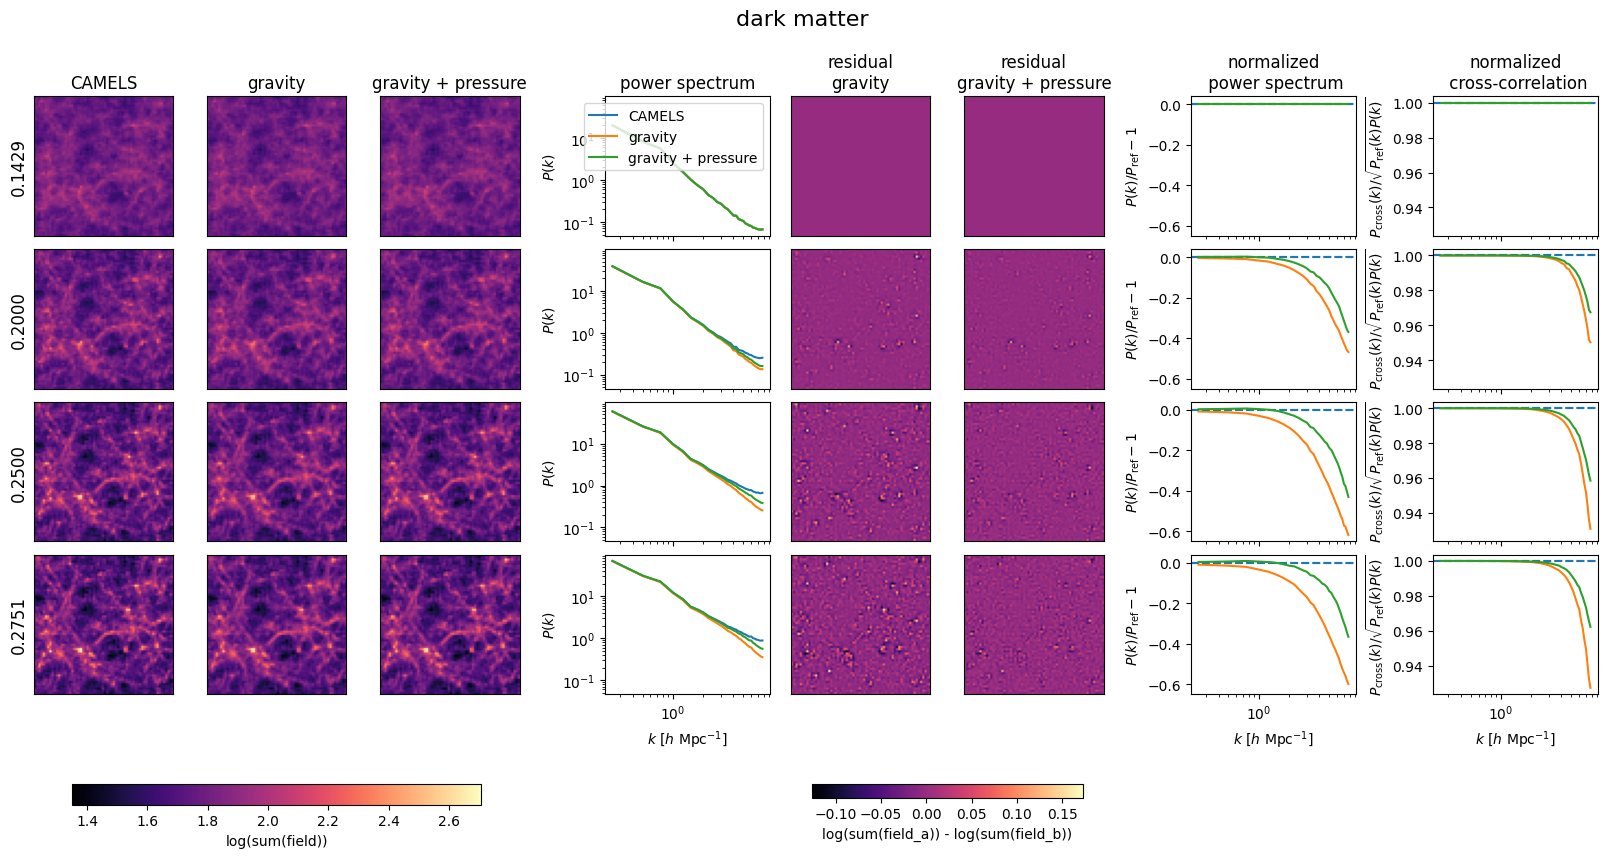

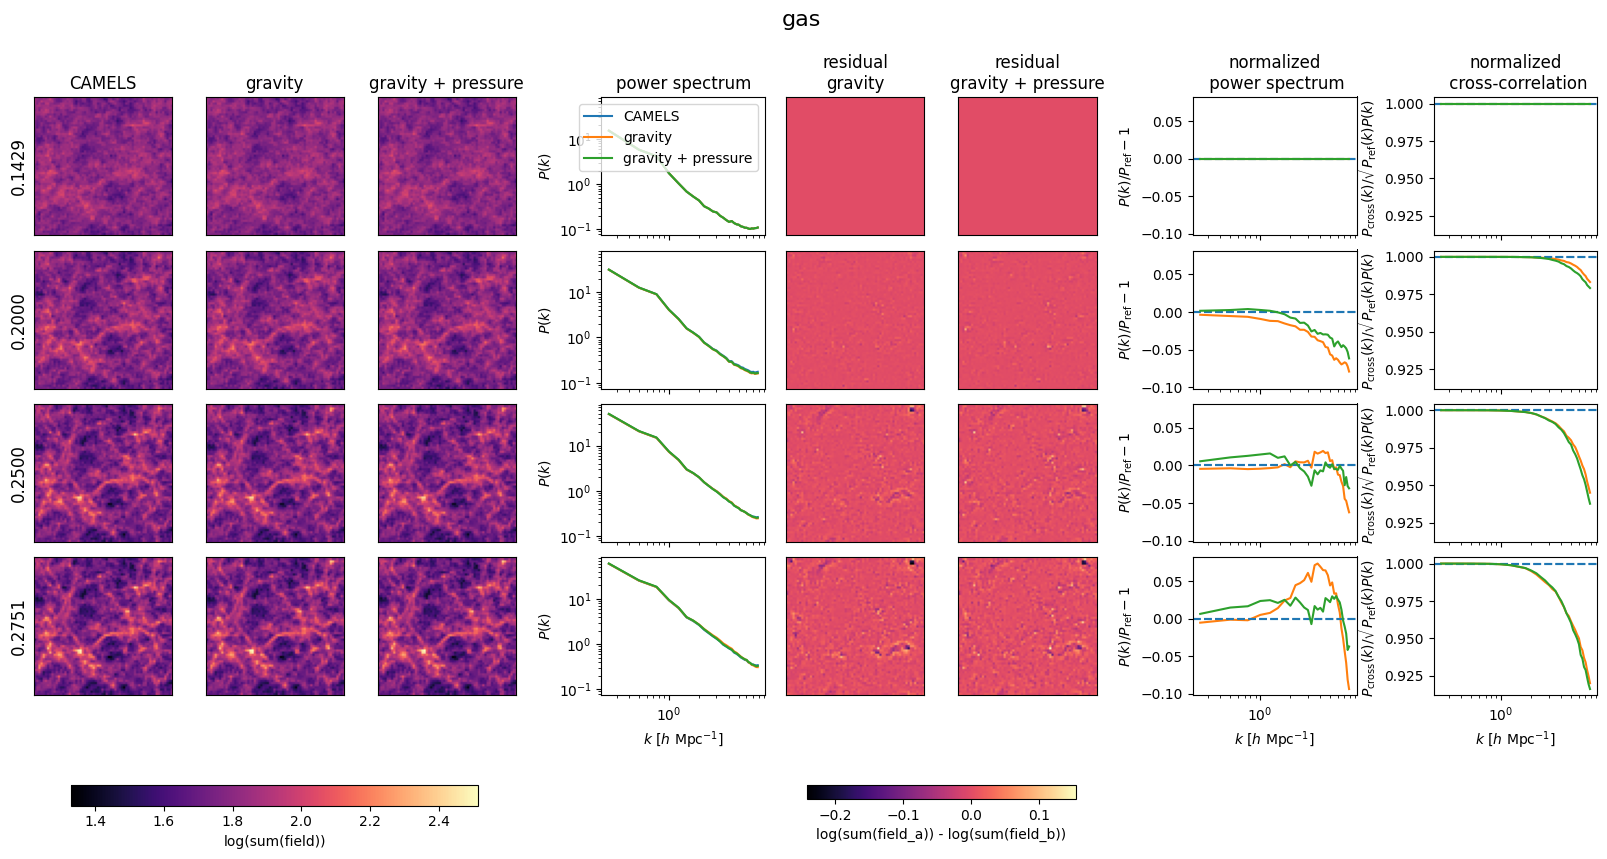

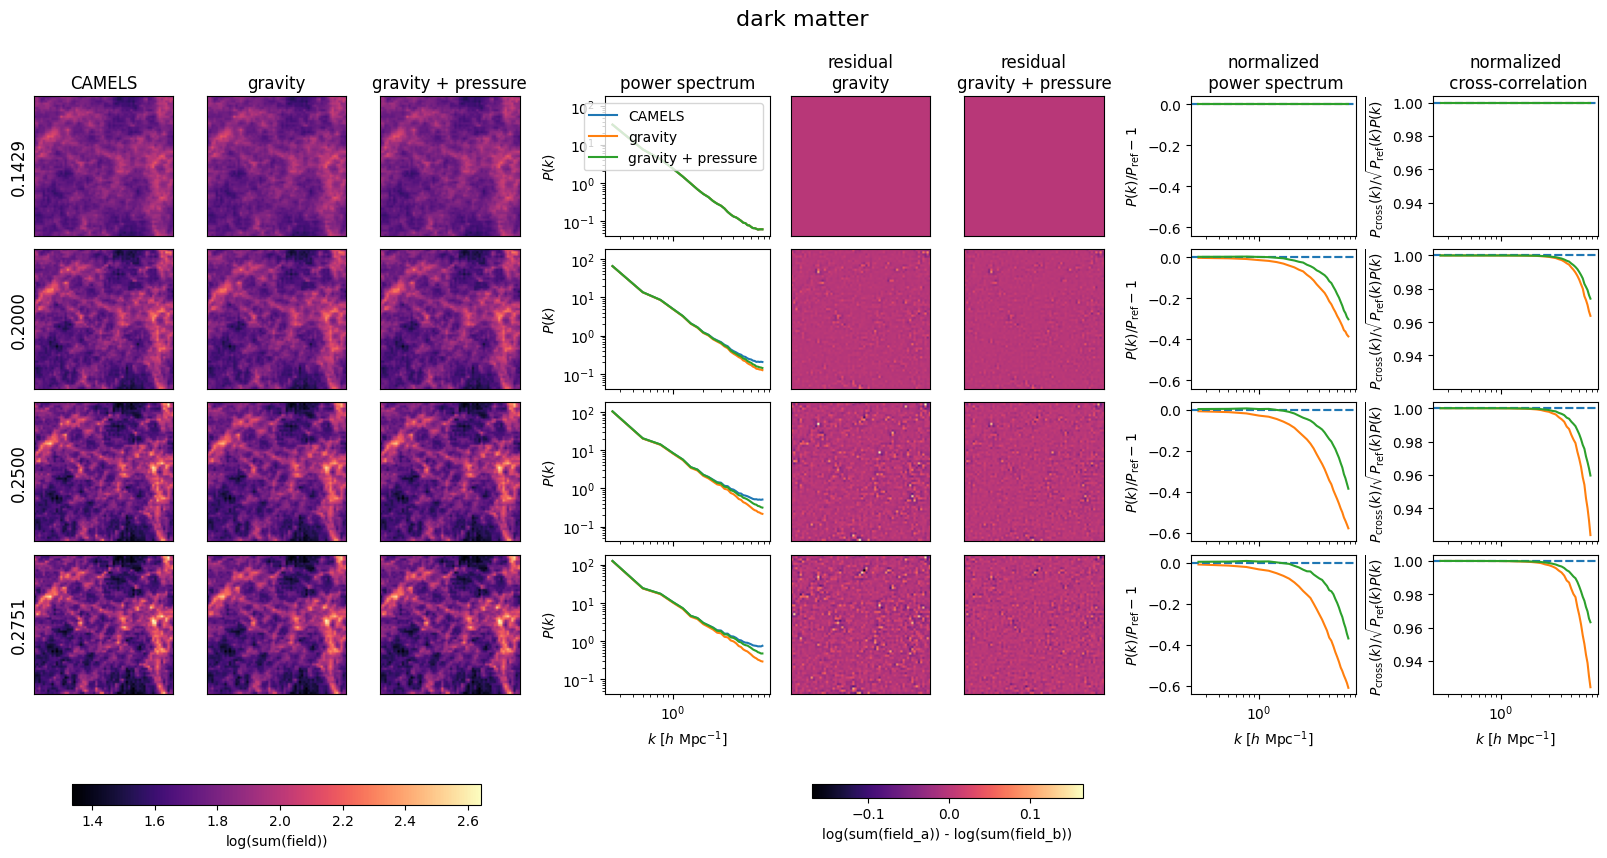

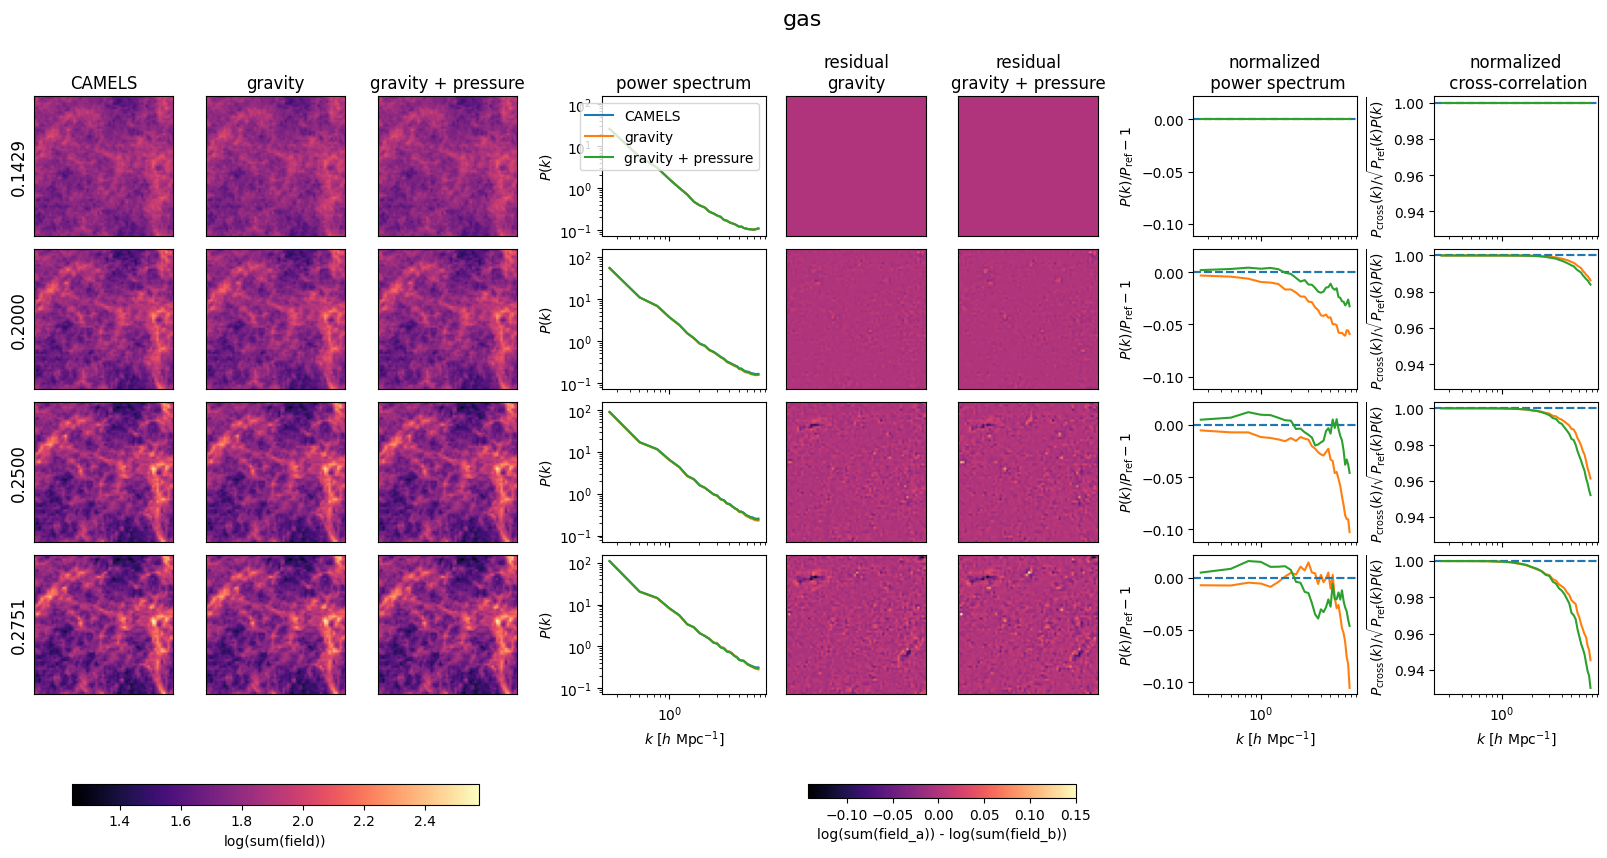

In [48]:
for camels_dict in [train_dict, vali_dict]:
    diagnostics.run_simulations(
        camels_dict,
        mesh_per_dim,
        gravity_model=gravity_model,
        pressure_model=pressure_model, 
        i_init=i0,
        # i_plot=i_loss,
        i_plot=i_loss[::2],
        # i_init=i_plot[0],
        # i_plot=i_plot,
        dt0=dt0,
        plot_dm=True,
        plot_gas=True,
    )

# debug

In [ ]:
nn_ode = hpm.get_hpm_network_ode_fn(
    mesh_per_dim,
    cosmo,
    gravity_model=gravity_model,
    pressure_model=pressure_model,
)

In [ ]:
nn_res = diffeqsolve(
    terms=ODETerm(nn_ode),
    solver=LeapfrogMidpoint(),
    t0=scales[i0],
    t1=scales[i_loss[-1]],
    dt0=dt0,
    y0=(dm_poss[i0], dm_vels[i0], gas_poss[i0], gas_vels[i0]),
    saveat=SaveAt(ts=scales[i_loss]),
    max_steps=1000,
    stepsize_controller=ConstantStepSize(),
)
nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys[:4]

In [ ]:
res_poss = nn_gas_poss
ref_poss = gas_poss[i_loss]

# pos loss

In [ ]:
dist = ((res_poss - ref_poss + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
pos_loss = jnp.sum(dist**2, axis=-1)
# pos_loss = jnp.sum(huber_loss((res_poss - ref_poss + mesh_per_dim // 2), mesh_per_dim // 2), axis=-1)
pos_loss = np.where(pos_loss < jnp.quantile(pos_loss, 0.9), pos_loss, 0.0)

In [ ]:
fig, ax = plt.subplots()
for i in range(pos_loss.shape[0]):
    current_pos_loss = pos_loss[i]
    ax.hist(current_pos_loss, bins=np.linspace(jnp.quantile(current_pos_loss, 0.01), jnp.quantile(current_pos_loss, 0.99), 100))

In [ ]:
def normalized_paint(positions, weights):
    rho_pos = cic_paint(jnp.zeros([mesh_per_dim] * 3), positions)
    pos_rho = cic_read(rho_pos, positions)

    return cic_paint(jnp.zeros(mesh_shape), positions, weights/pos_rho)

def plot_field(field, ax, vlims=None):
    log_sum = jnp.log10(field.sum(axis=0))

    if vlims is None:
        vmin, vmax = log_sum.min(), log_sum.max()
        vlims = (vmin, vmax)
    else:
        vmin, vmax = vlims

    im = ax.imshow(log_sum, cmap="magma", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.6, aspect=10)
    
    return im, vlims, log_sum

In [ ]:
i_ex = -1
gas_pos = gas_poss[i_ex]
loss_ex = pos_loss[i_ex]

rho_gas  = cic_paint(jnp.zeros([mesh_per_dim] * 3), gas_pos)
loss_field = normalized_paint(gas_pos, loss_ex)

In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

im = ax.scatter(gas_pos[:, 0], gas_pos[:, 1], gas_pos[:, 2], c=loss_ex, cmap="viridis", marker="o", alpha=0.3, s=0.01)
fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.8, aspect=20)

In [ ]:
fig, ax = plt.subplots()
for i in range(pos_loss.shape[0]):
    ax.hist(jnp.log(loss_field.sum(axis=0)).flatten(), bins=100)

In [ ]:
fig, ax = plt.subplots(ncols=2)

im0 = ax[0].imshow(jnp.log(rho_gas.sum(axis=0)))
im1 = ax[1].imshow(jnp.log(loss_field.sum(axis=0)))

fig.colorbar(im0, ax=ax[0], orientation="horizontal", shrink=0.6, aspect=10)
fig.colorbar(im1, ax=ax[1], orientation="horizontal", shrink=0.6, aspect=10)

# field loss

In [ ]:
i_ex = -1
res_pos = res_poss[i_ex]
ref_delta = deltas_gas[i_ex]

res_rho = cic_paint(jnp.zeros([mesh_per_dim] * 3), res_pos)
res_delta = res_rho/res_rho.mean() - 1 

field_loss = (res_delta - ref_delta) ** 2

In [ ]:
field_loss.shape

In [ ]:
fig, ax = plt.subplots()

ax.hist(field_loss.flatten(), bins=np.linspace(np.quantile(field_loss, 0.01), np.quantile(field_loss, 0.90), 100));

In [ ]:
fig, ax = plt.subplots(ncols=3)

im0 = ax[0].imshow(jnp.log(ref_rho.sum(axis=0)))
im1 = ax[0].imshow(jnp.log(res_rho.sum(axis=0)))
im2 = ax[1].imshow(jnp.log((field_loss).sum(axis=0)))

fig.colorbar(im0, ax=ax[0], orientation="horizontal", shrink=0.6, aspect=10)
fig.colorbar(im1, ax=ax[1], orientation="horizontal", shrink=0.6, aspect=10)
fig.colorbar(im2, ax=ax[2], orientation="horizontal", shrink=0.6, aspect=10)

ax[0].set(title="rho gas (CAMELS)")
ax[1].set(title="rho gas (HPM)")
ax[2].set(title="rho loss")